# Find garage work — (N) building-permit datasets

Same pipeline as `find_garage.ipynb`, run on the newer "(N)" LADBS building-permit pair, then compared against the `hbkd-qubn` results.

**Datasets** (identical 38-col schema, refreshed daily):
- `dyxf-7hc4` — Building Permits Issued 2010–2019 (~533k rows)
- `pi9x-tg5x` — Building Permits Issued 2020–present (~400k rows)

Downloaded via `download_permits_n.py` to `data/01_raw/permits/ladbs_building_permits_*.parquet`.

**Why these are better than `hbkd-qubn`**: `apn` (direct parcel link), untruncated `work_desc`, `du_changed`/`adu_changed`/`junior_adu` flags, lat/lon + census tract, CofO date, current through 2026. **Trade-off**: Building permit group only — no Electrical/Plumbing/HVAC/Fire Sprinkler trade permits.

Detection patterns are imported from `garage_taxonomy.py` (single source of truth, same patterns as `find_garage.ipynb`).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from garage_taxonomy import CATEGORIES, CATEGORY_PATTERNS, GARAGE_PAT, flag_and_categorize

pd.set_option("display.max_colwidth", None)

PERMITS_DIR = Path("/Users/adamswietek/Documents/PostDoc/HiddenHousing/data/01_raw/permits")

df = pd.concat(
    [
        pd.read_parquet(PERMITS_DIR / "ladbs_building_permits_2010_2019.parquet"),
        pd.read_parquet(PERMITS_DIR / "ladbs_building_permits_2020_present.parquet"),
    ],
    ignore_index=True,
)
print(f"{len(df):,} permits, {df.issue_date.min():%Y-%m-%d} to {df.issue_date.max():%Y-%m-%d}")
df.head(2)

932,939 permits, 2010-01-02 to 2026-07-04


,permit_nbr,primary_address,zip_code,cd,pin_nbr,apn,zone,apc,cpa,cnc,...,refresh_time,hl,submitted_date,cofo_date,square_footage,construction,height,du_changed,adu_changed,junior_adu
0,13016-20000-11826,8055 N SHADYGLADE AVE,91605,6,189B165 230,2309003001,RS-1,North Valley,Sun Valley - La Tuna Canyon,North Hollywood Northeast,...,2026-07-05,<NA>,NaT,NaT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,18016-40000-15870,1712 S PELICAN AVE,90732,15,012B189 127,7562008028,R1-1XL,Harbor,San Pedro,Coastal San Pedro,...,2026-07-05,YES,2018-05-18,NaT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


## Flag garage mentions and categorize the work

Same two-step logic as before: flag any garage/carport mention (incl. misspellings), then assign a work category in priority order (`conversion` > `demolition` > `new` > `addition` > `alteration`, else `incidental`).

In [2]:
garage = flag_and_categorize(df, "work_desc")

print(f"garage mentions: {len(garage):,} / {len(df):,} ({len(garage) / len(df):.1%})")
garage["garage_category"].value_counts()

garage mentions: 119,603 / 932,939 (12.8%)


garage_category
conversion    34931
new           27387
incidental    22742
demolition    20862
addition       8503
alteration     5178
Name: count, dtype: int64

In [3]:
# eyeball samples per category to tune the patterns
for cat in CATEGORIES:
    sub = garage[garage.garage_category == cat]
    print(f"\n=== {cat} ({len(sub):,}) ===")
    for s in sub["work_desc"].sample(min(8, len(sub)), random_state=0):
        print("  -", s)


=== conversion (34,931) ===
  - CONVERSION OF (E) ATTACHED GARAGE TO AN ADU, WITH  ADDITION PER LAMC 12.22 A.33(c) AND (e).  REPAIR (E) GARAGE WALLS AND ROOF FROM FIRE DAMAGE.
  - Addition of 18'x18' carport to existing single family dwelling per la city standard plan. Convert existing garage to bedroom and convert bedroom to study room.
  - CONVERT THE ATTACHED GARAGE TO ACCESSORY DWELLING UNITY PER AB 494 AND SB 229.  ALL  WORKS ARE PER WFPP
  - CONVERT 20' X 22' ATTACHED CARPORT TO GARAGE AND RE-STUCCO PORTION OF (E) SFD PER WFPP
  - RENOVATION & ADDITION TO (E) SFD W/ ATTACHED GARAGE. Work includes enclosing (E) patio on the 1st floor and convert portion of it to part of garage; converting (E) storage room to recreation room; reconfiguring (E) exterior stair to enclosed stair and replace (E) rear exterior stair.
  - CONVERT (E) ATTACHED GARAGE TO A JUNIOR ACCESSORY DWELLING UNIT PER GC  66323(a)(1) and 66333
  - CONVERT EX 21'X20'10" ATT GARAGE INTO JR ACCESSORY DWELLING UNIT PER 

## Validate `conversion` against the LADBS `adu_changed` flag

These datasets carry LADBS's own dwelling-unit-change flags, which the old dataset lacked. `adu_changed >= 1` on a garage-mention permit is a strong sign the permit legalizes/creates a dwelling — a ground-truth-ish check on our regex `conversion` label. (Not exact truth: an ADU can be new construction rather than a conversion, and pre-2017 permits predate the ADU statute.)

In [4]:
garage["adu_flag"] = garage["adu_changed"].fillna(0) >= 1

print(pd.crosstab(garage["garage_category"], garage["adu_flag"], margins=True))

conv = garage[garage.garage_category == "conversion"]
adu = garage[garage.adu_flag]
print(f"\nP(adu_changed | conversion)          = {conv.adu_flag.mean():.1%}   (post-2017: "
      f"{conv[conv.issue_date >= '2017'].adu_flag.mean():.1%})")
print(f"P(conversion | adu_changed & garage) = {(adu.garage_category == 'conversion').mean():.1%}")

adu_flag         False   True     All
garage_category                      
conversion       11848  23083   34931
demolition       20600    262   20862
new              25436   1951   27387
addition          7294   1209    8503
alteration        5135     43    5178
incidental       20347   2395   22742
All              90660  28943  119603

P(adu_changed | conversion)          = 66.1%   (post-2017: 76.7%)
P(conversion | adu_changed & garage) = 79.8%


In [5]:
# what are the adu_changed garage permits that we did NOT call conversion?
miss = garage[garage.adu_flag & (garage.garage_category != "conversion")]
print(miss.garage_category.value_counts(), "\n")
for cat, sub in miss.groupby("garage_category", observed=True):
    print(f"=== {cat} ({len(sub):,}) ===")
    for s in sub["work_desc"].sample(min(5, len(sub)), random_state=0):
        print("  -", s)

garage_category
incidental    2395
new           1951
addition      1209
demolition     262
alteration      43
conversion       0
Name: count, dtype: int64 

=== demolition (262) ===
  - CONVERT (E) SINGLE FAMILY DWELLING TO NEW ACCESSORY DWELLING UNIT PER LAMC 12.22 A.33(c) AND (d); EQUIPPED WITH NFPA 13-D FIRE SPRINKLERS THROUGHOUT; 9'-6" x 20' BREEZEWAY TO REMAIN; REMOVE 10'X 20' BREEZEWAY TO DETACH ADU FROM GARAGE AND ACCESSORY LIVING QUARTERS
  - REMOVE  EX DET (23'4"X12'2") GARAGE EXCEPT 2' OF EX EXT WALL AND CONSTRUCT  (45'X25') ACCESSORY DWELLING UNIT PER ORD #186,481 W/ ADDITION & (5'X11'8") TRELLIS OVER FRONT PORCH. ALL WORK PER ENGR.
  - REMOVE (E) WORKSHOP AND ADD DETACHED (N) 1 STORY ADU TO (E) 2 CAR GARAGE PER LAMC 12.22 A.33 (c)-(d)
  - SUPPLEMENTAL TO PERMIT 18016-10000-02370 TO CONVERT EXISTING REC-ROOM TO  ACCESSORY DWELLING UNIT  PER AB 494 AND SB 229. AND REMOVE NEW CARPORT FROM SCOPE OF WORK
  - *ePLAN CHECK* CONVERSION OF 1,852 SQ FT PORTION OF (E) SINGLE FAMILY D

## Annual totals by category

2026 is a partial year (data end early July), drawn dashed.

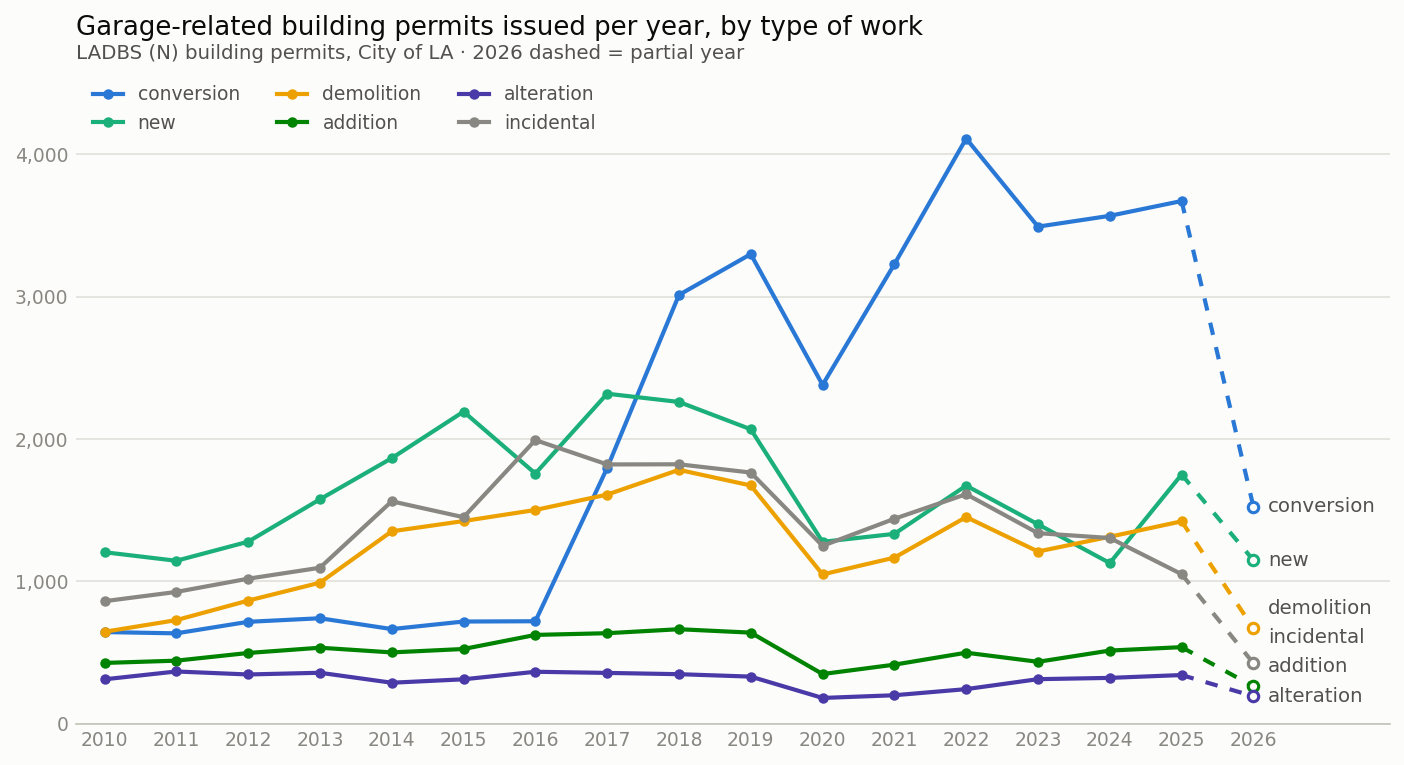

garage_category,conversion,new,demolition,addition,alteration,incidental
year,,,,,,
2010,644,1205,646,427,312,861
2011,635,1145,728,443,367,926
2012,716,1279,865,497,346,1019
2013,741,1577,991,534,358,1096
2014,665,1866,1352,501,288,1563
2015,718,2193,1424,525,312,1451
2016,720,1758,1502,624,365,1993
2017,1797,2319,1610,636,357,1822
2018,3013,2261,1784,664,348,1823


In [6]:
SURFACE, GRID, BASELINE = "#fcfcfb", "#e1e0d9", "#c3c2b7"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"

CAT_COLORS = {
    "conversion": "#2a78d6",
    "new":        "#1baf7a",
    "demolition": "#eda100",
    "addition":   "#008300",
    "alteration": "#4a3aa7",
    "incidental": "#898781",
}

annual = (
    garage.assign(year=garage.issue_date.dt.year)
    .groupby(["year", "garage_category"], observed=True).size()
    .unstack(fill_value=0)
    .reindex(columns=list(CAT_COLORS))
)

LAST_YEAR = annual.index.max()
LAST_FULL_YEAR = LAST_YEAR - 1  # data end early July: draw the partial year dashed

fig, ax = plt.subplots(figsize=(9.5, 5.2), dpi=150, facecolor=SURFACE)
ax.set_facecolor(SURFACE)

full = annual.index[annual.index <= LAST_FULL_YEAR]
for cat, color in CAT_COLORS.items():
    s = annual[cat]
    ax.plot(full, s.loc[full], color=color, lw=2, marker="o", ms=4, label=cat)
    ax.plot([LAST_FULL_YEAR, LAST_YEAR], s.loc[[LAST_FULL_YEAR, LAST_YEAR]],
            color=color, lw=2, ls=(0, (3, 3)))
    ax.plot(LAST_YEAR, s.loc[LAST_YEAR], marker="o", ms=5, mfc=SURFACE, mec=color, mew=1.5)

# direct labels at the right edge, spread to avoid collisions
ends = sorted([(annual[c].loc[LAST_YEAR], c) for c in CAT_COLORS])
min_gap = annual.values.max() * 0.05
ys = []
for v, c in ends:
    ys.append(v if not ys else max(v, ys[-1] + min_gap))
for (v, c), y in zip(ends, ys):
    ax.annotate(c, xy=(LAST_YEAR, v), xytext=(LAST_YEAR + 0.2, y), va="center",
                fontsize=9.5, color=INK2)

ax.set_xlim(annual.index.min() - 0.4, LAST_YEAR + 1.9)
ax.set_ylim(0, annual.values.max() * 1.12)
ax.set_xticks(annual.index)
ax.tick_params(colors=MUTED, labelsize=9, length=0)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.grid(axis="y", color=GRID, lw=0.8)
ax.set_axisbelow(True)
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color(BASELINE)

ax.set_title("Garage-related building permits issued per year, by type of work",
             loc="left", fontsize=12.5, color=INK, pad=16)
ax.text(0, 1.015,
        f"LADBS (N) building permits, City of LA · {LAST_YEAR} dashed = partial year",
        transform=ax.transAxes, fontsize=9.5, color=INK2)
ax.legend(loc="upper left", frameon=False, fontsize=9, ncols=3,
          labelcolor=INK2, handlelength=1.6)

FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
fig.tight_layout()
fig.savefig(FIG_DIR / "garage_permits_annual_by_category_n.png", facecolor=SURFACE)
plt.show()

annual

## Comparison with the `hbkd-qubn` results

Apples-to-apples scope: **Building-group permit types only** (the (N) pair has no trade permits) and **issue dates in the overlap window** 2013-01-01 to 2023-05-19 (the old snapshot's coverage). The old dataset is re-flagged with the same shared patterns.

Two questions:
1. Do the category totals move once descriptions aren't truncated at ~70 chars?
2. On permits present in both, how often does the full text change the assigned category?

In [7]:
old = pd.read_parquet(PERMITS_DIR / "ladbs_permits_hbkd-qubn.parquet")

WINDOW = ("2013-01-01", "2023-05-19")
building_types = set(df.permit_type.dropna().unique())

old_w = old[old.permit_type.isin(building_types) & old.issue_date.between(*WINDOW)]
new_w = df[df.issue_date.between(*WINDOW)]
print(f"old (building types, window): {len(old_w):,}   new (window): {len(new_w):,}")

old_garage = flag_and_categorize(old_w, "work_description")
new_garage = flag_and_categorize(new_w, "work_desc")

comparison = pd.DataFrame({
    "hbkd-qubn (truncated)": old_garage.garage_category.value_counts(),
    "(N) pair (full text)": new_garage.garage_category.value_counts(),
})
comparison["diff"] = comparison.iloc[:, 1] - comparison.iloc[:, 0]
print(f"\ngarage mentions: old {len(old_garage):,}  new {len(new_garage):,}")
comparison

old (building types, window): 612,513   new (window): 606,258

garage mentions: old 61,860  new 80,464


,hbkd-qubn (truncated),(N) pair (full text),diff
garage_category,,,
conversion,18071,22037,3966
demolition,13181,14488,1307
new,13278,18916,5638
addition,3040,5568,2528
alteration,2090,3076,986
incidental,12200,16379,4179


In [8]:
# permit-level agreement on permits present in both datasets
merged = old_garage[["pcis_permit", "garage_category", "work_description"]].merge(
    new_garage[["permit_nbr", "garage_category", "work_desc"]],
    left_on="pcis_permit", right_on="permit_nbr",
    suffixes=("_old", "_new"),
)
agree = (merged.garage_category_old == merged.garage_category_new).mean()
print(f"matched permits: {len(merged):,}   category agreement: {agree:.1%}\n")

print(pd.crosstab(merged.garage_category_old, merged.garage_category_new,
                  rownames=["old (truncated)"], colnames=["new (full text)"]))

matched permits: 61,100   category agreement: 97.3%

new (full text)  conversion  demolition    new  addition  alteration  \
old (truncated)                                                        
conversion            17952           0      1         0           0   
demolition              120       12932      0         0           0   
new                      54          24  13033         0           0   
addition                224          14     92      2657           0   
alteration               62          31     91        43        1840   
incidental              292          83    246       176         127   

new (full text)  incidental  
old (truncated)              
conversion                0  
demolition                0  
new                       0  
addition                  0  
alteration                0  
incidental            11006  


In [9]:
# where the full text changed the category, what did truncation hide?
changed = merged[merged.garage_category_old != merged.garage_category_new]
print(f"{len(changed):,} permits change category with full text\n")
for _, row in changed.sample(min(8, len(changed)), random_state=0).iterrows():
    print(f"[{row.garage_category_old} -> {row.garage_category_new}]")
    print(f"  old: {row.work_description}")
    print(f"  new: {row.work_desc}\n")

1,680 permits change category with full text

[demolition -> conversion]
  old: REMOVE (E) ONE CAR CARPORT & PATIO , 17'-0" X 12'-0" ADDITION AND CONV
  new: REMOVE (E) ONE CAR CARPORT & PATIO , 17'-0" X 12'-0" ADDITION AND CONVERT 14'-6" X 24'-6" PORTION OF  (E) SFD TO ACCESSORY DWELLING UNIT PER AB 494 AND SB 229, 11'-6" X 12'-0" LAUNDRY ROOM ADDITION TO (E) SFD. ALL WORK DONE PER WFPP.

[demolition -> conversion]
  old: REMOVE 10'-2" X  20' BREEZEWAY TO DETACH EXISTING GARAGE; ADD 23' X 42
  new: REMOVE 10'-2" X  20' BREEZEWAY TO DETACH EXISTING GARAGE; ADD 23' X 42'-6"  IRREGULAR SHAPED TO AND CONVERT GARAGE TO ACCESSORY DWELING UNIT PER AB 494 & SB 229

[addition -> new]
  old: VOLUNTARY SEISMIC RETROFIT FOR GARAGE BELOW SFD - add OMF @ garage ope
  new: VOLUNTARY SEISMIC RETROFIT FOR GARAGE BELOW SFD - add OMF @ garage opening and new shear walls

[addition -> conversion]
  old: ADD 12' X 6'1" TRELLIS TO DETACHED GARGE AND REFRAME GARAGE ROOF, CONV
  new: ADD 12' X 6'1" TRELLIS T

In [10]:
# how much text was the truncation actually costing?
old_len = old_w["work_description"].str.len()
new_len = new_w["work_desc"].str.len()
print(f"work_description length, old: median {old_len.median():.0f}, "
      f"p95 {old_len.quantile(0.95):.0f}, max {old_len.max():.0f}")
print(f"work_desc        length, new: median {new_len.median():.0f}, "
      f"p95 {new_len.quantile(0.95):.0f}, max {new_len.max():.0f}")
print(f"share of old descriptions at the ~70-char cap: "
      f"{(old_len >= 69).mean():.1%}")

work_description length, old: median 70, p95 70, max 70
work_desc        length, new: median 111, p95 380, max 1831
share of old descriptions at the ~70-char cap: 75.5%


In [20]:
garage.groupby(['garage_category'])['permit_sub_type'].value_counts().unstack()

permit_sub_type,1 or 2 Family Dwelling,Apartment,Commercial,Onsite
garage_category,,,,
conversion,33397,1130,403,1
demolition,19538,973,351,<NA>
new,23993,2474,916,4
addition,8164,204,133,2
alteration,4448,577,152,1
incidental,20703,1440,570,29


In [21]:
garage.to_csv(PERMITS_DIR / "garage_permits_2010_present.csv", index=False)

In [11]:
# persist the flagged + categorized subset for downstream work
OUT = PERMITS_DIR.parent.parent / "02_interm" / "permits_garage_n.parquet"
OUT.parent.mkdir(parents=True, exist_ok=True)
garage.to_parquet(OUT, index=False)
print(f"wrote {len(garage):,} garage-mention permits -> {OUT}")

wrote 119,603 garage-mention permits -> /Users/adamswietek/Documents/PostDoc/HiddenHousing/data/02_interm/permits_garage_n.parquet


## Takeaways (first run, 2026-07-07)

- **119,603 garage mentions** out of 932,939 building permits (12.8%) — a much higher hit rate than in `hbkd-qubn` (3.9%) because trade permits (mostly noise) are excluded and descriptions are complete.
- **`adu_changed` validation**: 66% of regex `conversion` permits carry the ADU flag (77% post-2017; pre-2017 conversions predate the statute, so the flag can't fire). Conversely, 80% of ADU-flagged garage permits are labeled `conversion`. The biggest leakage is 2,395 ADU-flagged permits in `incidental` — many are true conversions the gap pattern misses because `[^.]*` stops at periods inside abbreviations ("SQ. FT.", "ATT.", "(E)... per GOV CODE 65852.2"). Fixing the sentence-gap logic in `garage_taxonomy.py` is the highest-value tuning step.
- **Truncation mattered**: 75.5% of old descriptions sit at the 70-char cap (new: median 111 chars, p95 380). In the overlap window the full text yields **80,464 garage mentions vs 61,860** (+30%) — mentions past char 70 were invisible before. On the 61,100 permits matched in both, category agreement is 97.3%; the 1,680 flips are mostly truncation hiding a later "CONVERT ... TO ADU" clause (net flow into `conversion`).
- **Annual trend** (now through 2026): conversions surge from ~700/yr pre-2017 to 3,000+ from 2018 on, peaking at 4,112 in 2022 and holding ~3,500/yr since — the dominant garage-work category every year since 2018.

Next steps:
1. Adopt the (N) pair as the primary source — it has `apn` for direct parcel linkage.
2. Fix the conversion gap pattern (periods in abbreviations), then re-validate against `adu_changed`.
3. Use `adu_changed` + `cofo_date` to build a legalization-event table per APN.
4. Keep `hbkd-qubn` only for trade-permit signals (electrical/plumbing at garage addresses, 2013–2023).